# AIMLZG546 | Assignment I | Group 54

## Credit Default Risk Review Prototype

**Group members and contributions:**

| Sl. No | BITS ID | Name | Contribution (Qualitative) | Percentage (out of 100) |
|---|---|---|---|---|
| 1 | 2025AE05017 | POONAM TANNA | Contributed across most project areas, collaborating on problem formulation, GR4ML views, system architecture, pattern implementation, Streamlit UI, and report generation. | 40 |
| 2 | 2025AE05791 | Mohammed Asif S | Requirements formulation: domain and problem statement, users and stakeholders, GR4ML measurable goals and indicators table, functional and non-functional requirements with acceptance criteria, and justification of the top three quality requirements. | 20 |
| 3 | 2025AF05145 | NAVEEN.K.B | GR4ML modelling: Business View, Analytics Design View and Data Preparation View (tables and diagrams), cross-view traceability, softgoal contribution links and decomposition correctness. | 20 |
| 4 | 2025AF05136 | SIMRAN SURI | Evaluation and reporting: model evaluation experiments (threshold sweep, fairness audit by subgroup), application testing and screenshots with captions, notebook execution and saved outputs, report compilation, formatting and consistency review between docx and notebook. | 20 |



## 1. Problem formulation and scope

**Domain:** financial risk management for existing credit-card accounts. **Problem statement:** use an account's historical credit limit, repayment status, billed amounts, and payment amounts to estimate the likelihood of payment default next month and prioritize an account for review by a credit-risk analyst. The prototype uses the UCI *Default of Credit Card Clients* dataset: 30,000 Taiwan credit-card accounts and a binary next-month default label. It is an educational benchmark, not a production credit-scoring service.

**Users and stakeholders:** credit-risk analyst (reviews a flag), model owner (validates and monitors), data steward (governs permitted use), customer (affected stakeholder), and service operator (availability/security). The prototype excludes the row identifier and sex, education, marital-status, and age fields from model inputs. Its controls are illustrative median-based profiles, not customer records.

**Dataset citation:** Yeh, I.-C. and Lien, C.-H. (2009), “The comparisons of data mining techniques for the predictive accuracy of probability of default of credit card clients,” *Expert Systems with Applications*, 36(2), 2473-2480. UCI Machine Learning Repository, [Default of Credit Card Clients](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients).


## 2. Requirements and measurable goals

### GR4ML Measurable Goals & Indicators Table

| Goal ID | GR4ML Goal Type | Goal Statement | Indicator (KPI) | Target Threshold | Prototype Holdout Result (t=0.50) |
|---|---|---|---|---|---|
| G-B1 | Strategic Goal | Support timely review of accounts with elevated default risk. | Default recall on the positive class | >=70% on independent later-period validation | Logistic regression 62.85%; Random forest 59.61%. |
| DG-1 | Decision Goal | Decide account review priority for analyst follow-up. | Default recall and specificity | >=70% for each on independent validation | Recall 62.85%/59.61%; specificity 68.69%/82.09% (LR/RF). |
| QG-1 | Question Goal | What is the account's next-month default probability? | Probability output in [0, 1] and correct threshold flag | Valid probability and correct threshold behavior for every request | Probability and threshold boundary are covered by the automated test suite; no calibration claim. |
| IND-1 | Indicator | Measure default detection effectiveness. | Recall = TP / (TP + FN) | >=70% on independent later-period validation | Logistic regression 62.85%; Random forest 59.61%. |
| IND-2 | Indicator | Measure correct non-default identification. | Specificity = TN / (TN + FP) | >=70% on independent later-period validation | Logistic regression 68.69%; Random forest 82.09%. |
| Q-B2 | Softgoal | Ensure no material demographic disparity in recall. | Maximum recall gap by sex or age band | <=5 percentage points before pilot | Logistic regression: 12.33pp (does not meet <=5pp); Random forest: 11.53pp (does not meet <=5pp). Coursework audit only; not a governed audit. |

### Functional and Nonfunctional Requirements

| ID | Requirement | Verification / acceptance |
|---|---|---|
| FR-1 | Load the bundled UCI account data; remove ID and excluded demographic fields; encode next-month default as positive class 1. | Schema, row-count, exclusion, and target checks. |
| FR-2 | Use a reproducible stratified 80/20 train/test split with seed 42. | Repeated split has the same records and class proportions. |
| FR-3 | Allow logistic-regression and random-forest model strategies. | Both strategies train and return valid probabilities. |
| FR-4 | Display recall, specificity, precision, accuracy, and a configurable threshold. | UI metrics match service results; test the threshold boundary. |
| FR-5 | Return estimated default probability and flag accounts at or above the threshold for analyst review. | Positive-class and boundary tests. |
| NFR-1 Effectiveness | Before any pilot, independently validate on later, representative data and meet default recall >=70% and specificity >=70%; otherwise block release. | Temporal/external holdout with a documented threshold and confusion matrix. Current benchmark does not meet both targets at threshold 0.50. |
| NFR-2 Fairness | Before any pilot, measure relevant subgroup error-rate gaps; require recall gap <=5 percentage points or block release. | Lawful, governed audit dataset; demographic fields are audit-only and excluded from model inputs. |
| NFR-3 Privacy | Do not retain identifiers, account inputs, or scores in the prototype; do not transmit data externally. | Inspect code, logging, and storage. |
| NFR-4 Performance / reliability | After model load, scoring p95 <2 seconds at 10 requests/second; production availability >=99% monthly. | Reference-environment load test and monitored SLO report. |

Targets are release criteria, not achieved claims. The notebook's random holdout is only a reproducible coursework demonstration and cannot substitute for temporal validation or governance.


## 3. GR4ML views

Notation used consistently: **G** = goal, **Q** = quality/softgoal, **A** = actor, **T** = task, **R** = resource, **BR** = business/data rule. AND-decomposition requires all child goals; OR-decomposition denotes alternatives. Dependencies are stated explicitly.

### 3.1 Business View

| Element | GR4ML statement |
|---|---|
| A-1 | Actor: credit-risk analyst reviews context and makes account decisions. |
| A-2 | Actor: ML service estimates next-month default probability. |
| A-3 | Actor: data steward governs provenance and fairness audit. |
| G-B1 | Strategic Goal: support timely review of elevated-risk accounts. |
| G-B2 | Decision Goal: prioritize accounts for analyst review (AND decomposition). |
| G-B2a | Valid feature input. |
| G-B2b | Risk estimate and review flag. |
| IND-1 | Indicator: Default Recall >=70% on independent validation; linked to Q-B1 and G-A1. |
| IND-2 | Indicator: Specificity >=70% on independent validation; linked to Q-B1 and G-A1. |
| Q-B1 | Softgoal: Decision Effectiveness, measured by IND-1 and IND-2. |
| Q-B2 | Softgoal: Demographic Fairness; maximum recall gap <=5pp before pilot. |
| T-B1 | Task: Analyst Account Review using approved conventional evidence. |
| BR-B1 | No automated credit approval, pricing, collections, adverse action, or customer decision. |
| BR-B2 | Exclude direct identifiers and demographics from model inputs; govern audit use. |

**Flow and dependencies:** G-B1 supports G-B2; G-B2 AND-decomposes to valid input (G-B2a) and an estimate/flag (G-B2b). G-B2b supports analyst review T-B1. IND-1 and IND-2 measure Q-B1 and trace to analytics goal G-A1. A-1 retains decision authority; A-3 governs approved data and audit use.

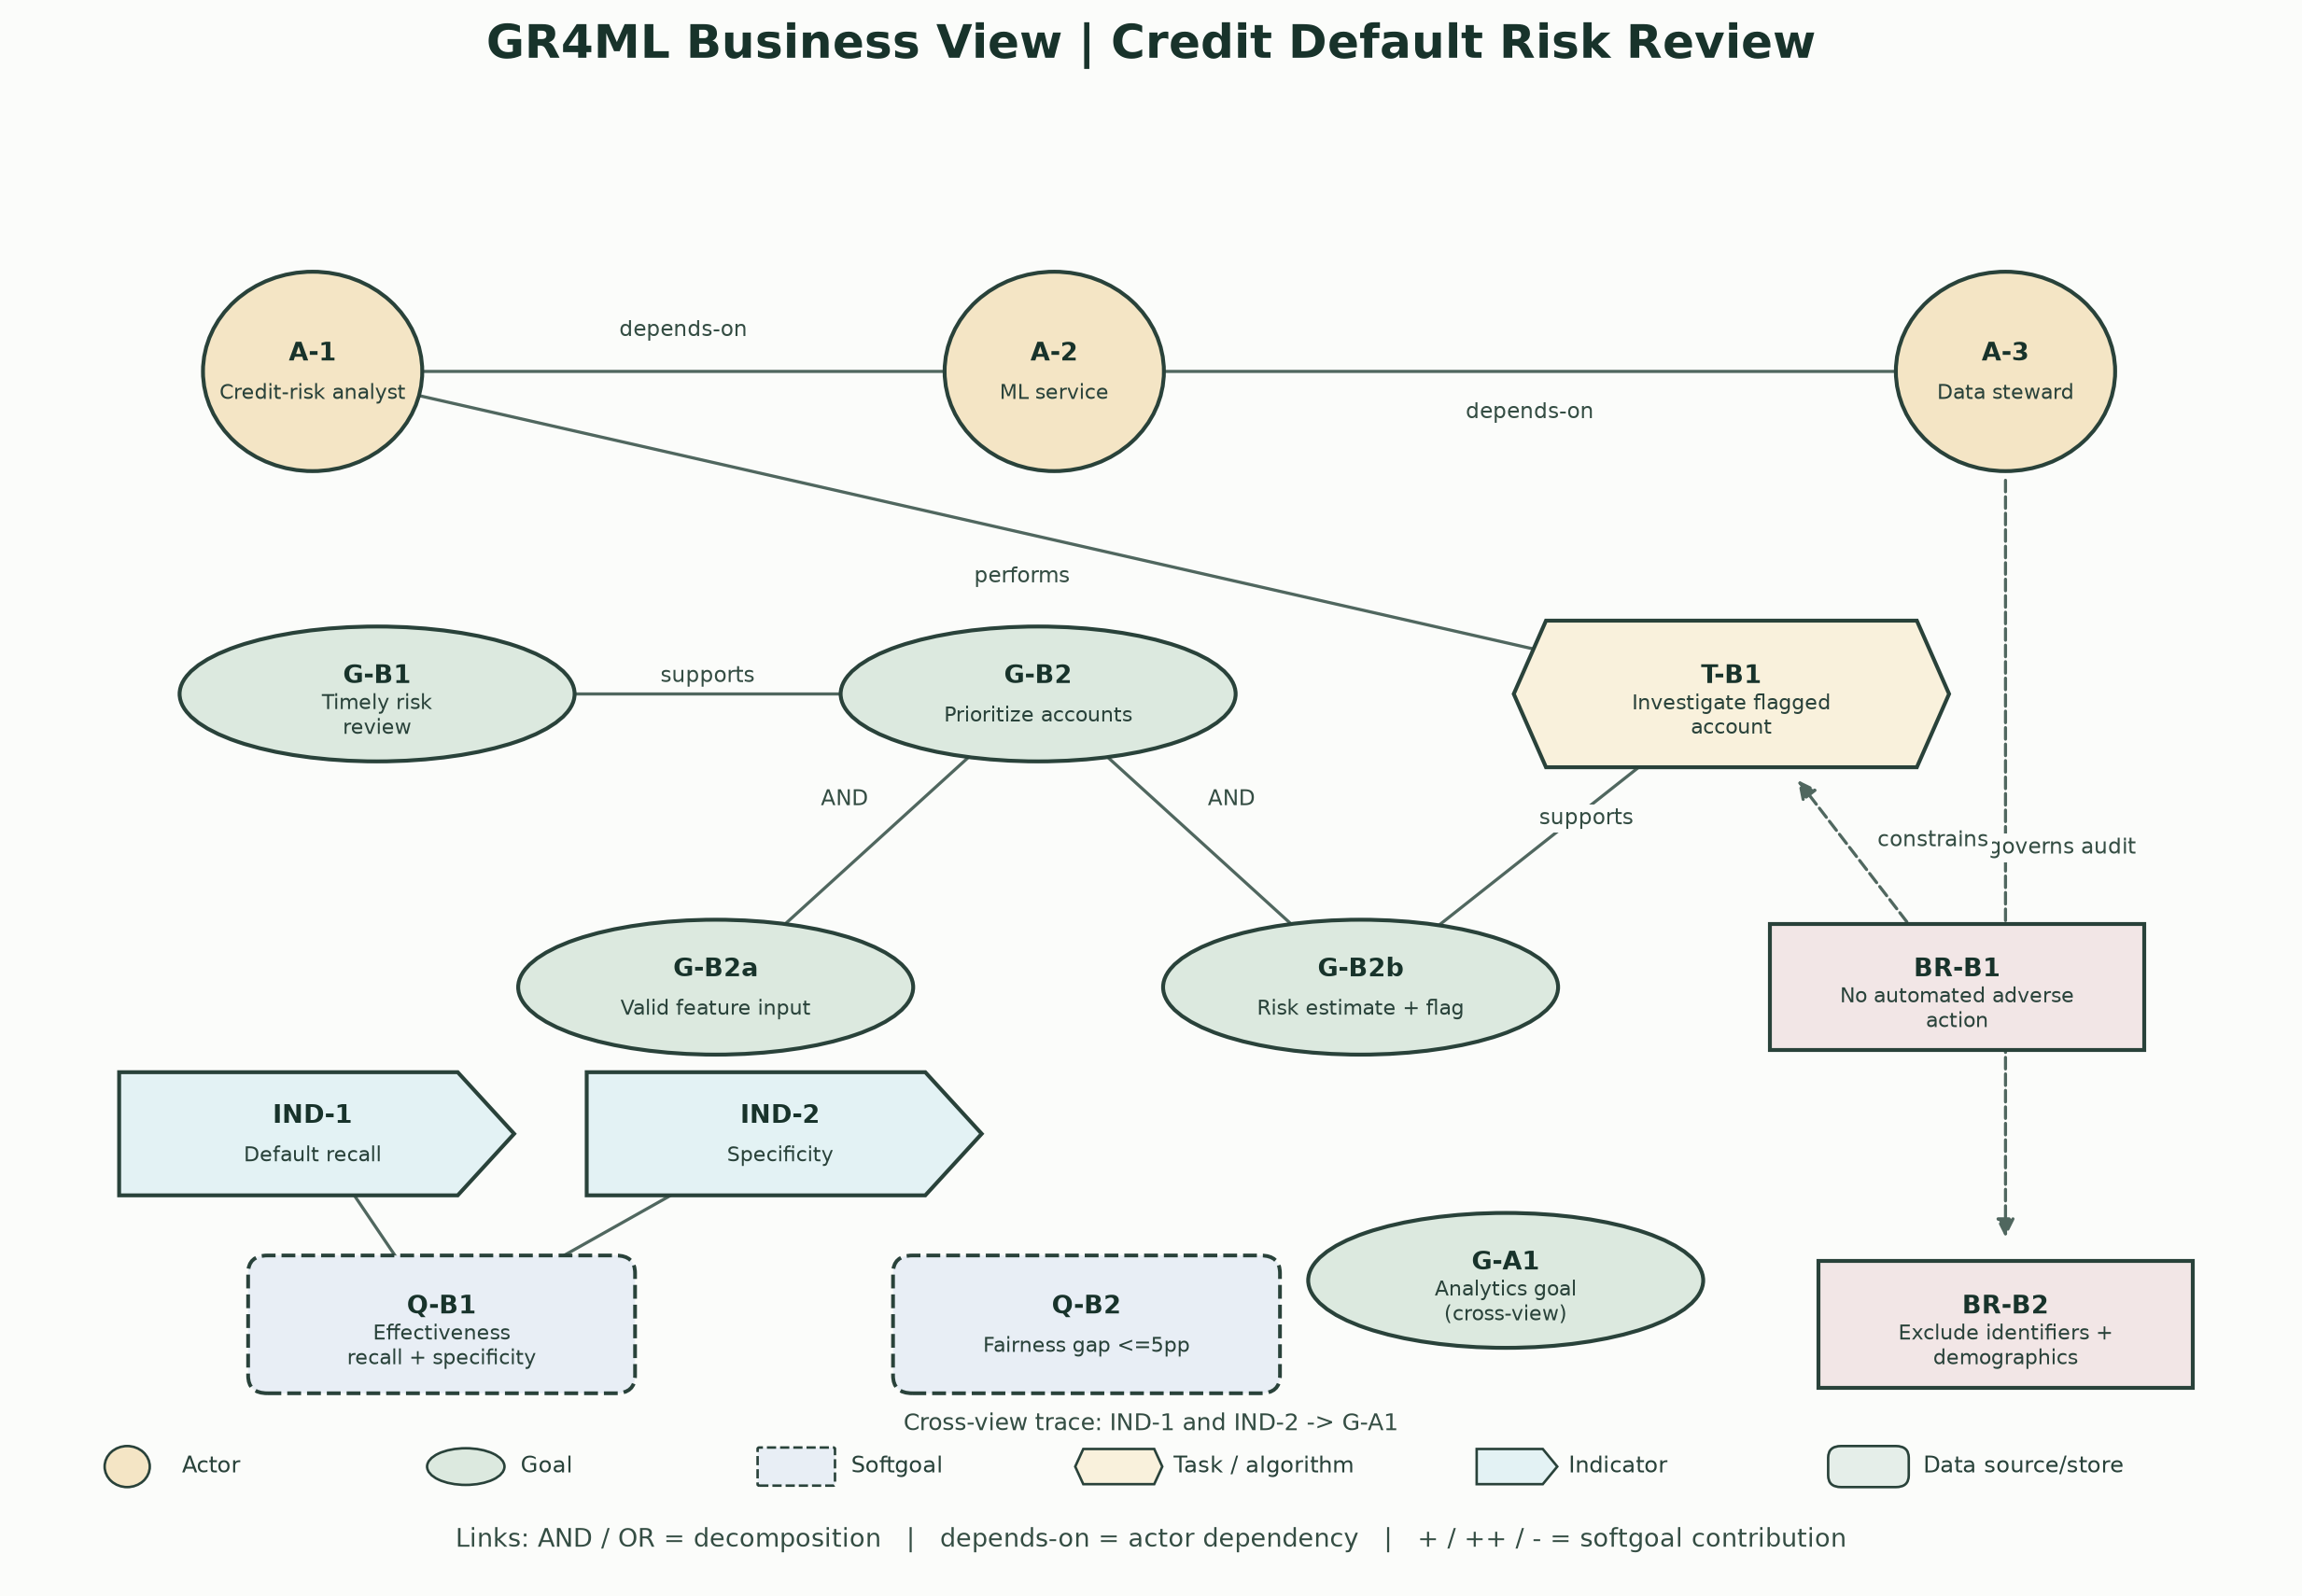

### 3.2 Analytics Design View

| Element | GR4ML statement |
|---|---|
| G-A1 | Analytics Goal: estimate next-month P(default) and support review. |
| T-A1 | Analytics Task: Supervised Binary Classification. |
| ALG-1 | Algorithm: Logistic Regression. |
| ALG-2 | Algorithm: Random Forest. |
| T-A2 | Task: evaluate the holdout confusion matrix and metrics at threshold 0.50. |
| IND-A1 | Indicator: Holdout Confusion Matrix & Metrics. |
| Q-A1 | Softgoal: Recall/Specificity Balance. |
| Q-A2 | Softgoal: Model Interpretability. |
| Q-A3 | Softgoal: Reproducibility (fixed seed and split). |
| BR-A1 | Default is positive class 1; select predict_proba column by class label. |

**OR decomposition:** T-A1 selects ALG-1 or ALG-2. Both implement the same model contract. Logistic regression contributes positively to interpretability; the less interpretable forest is a trade-off.

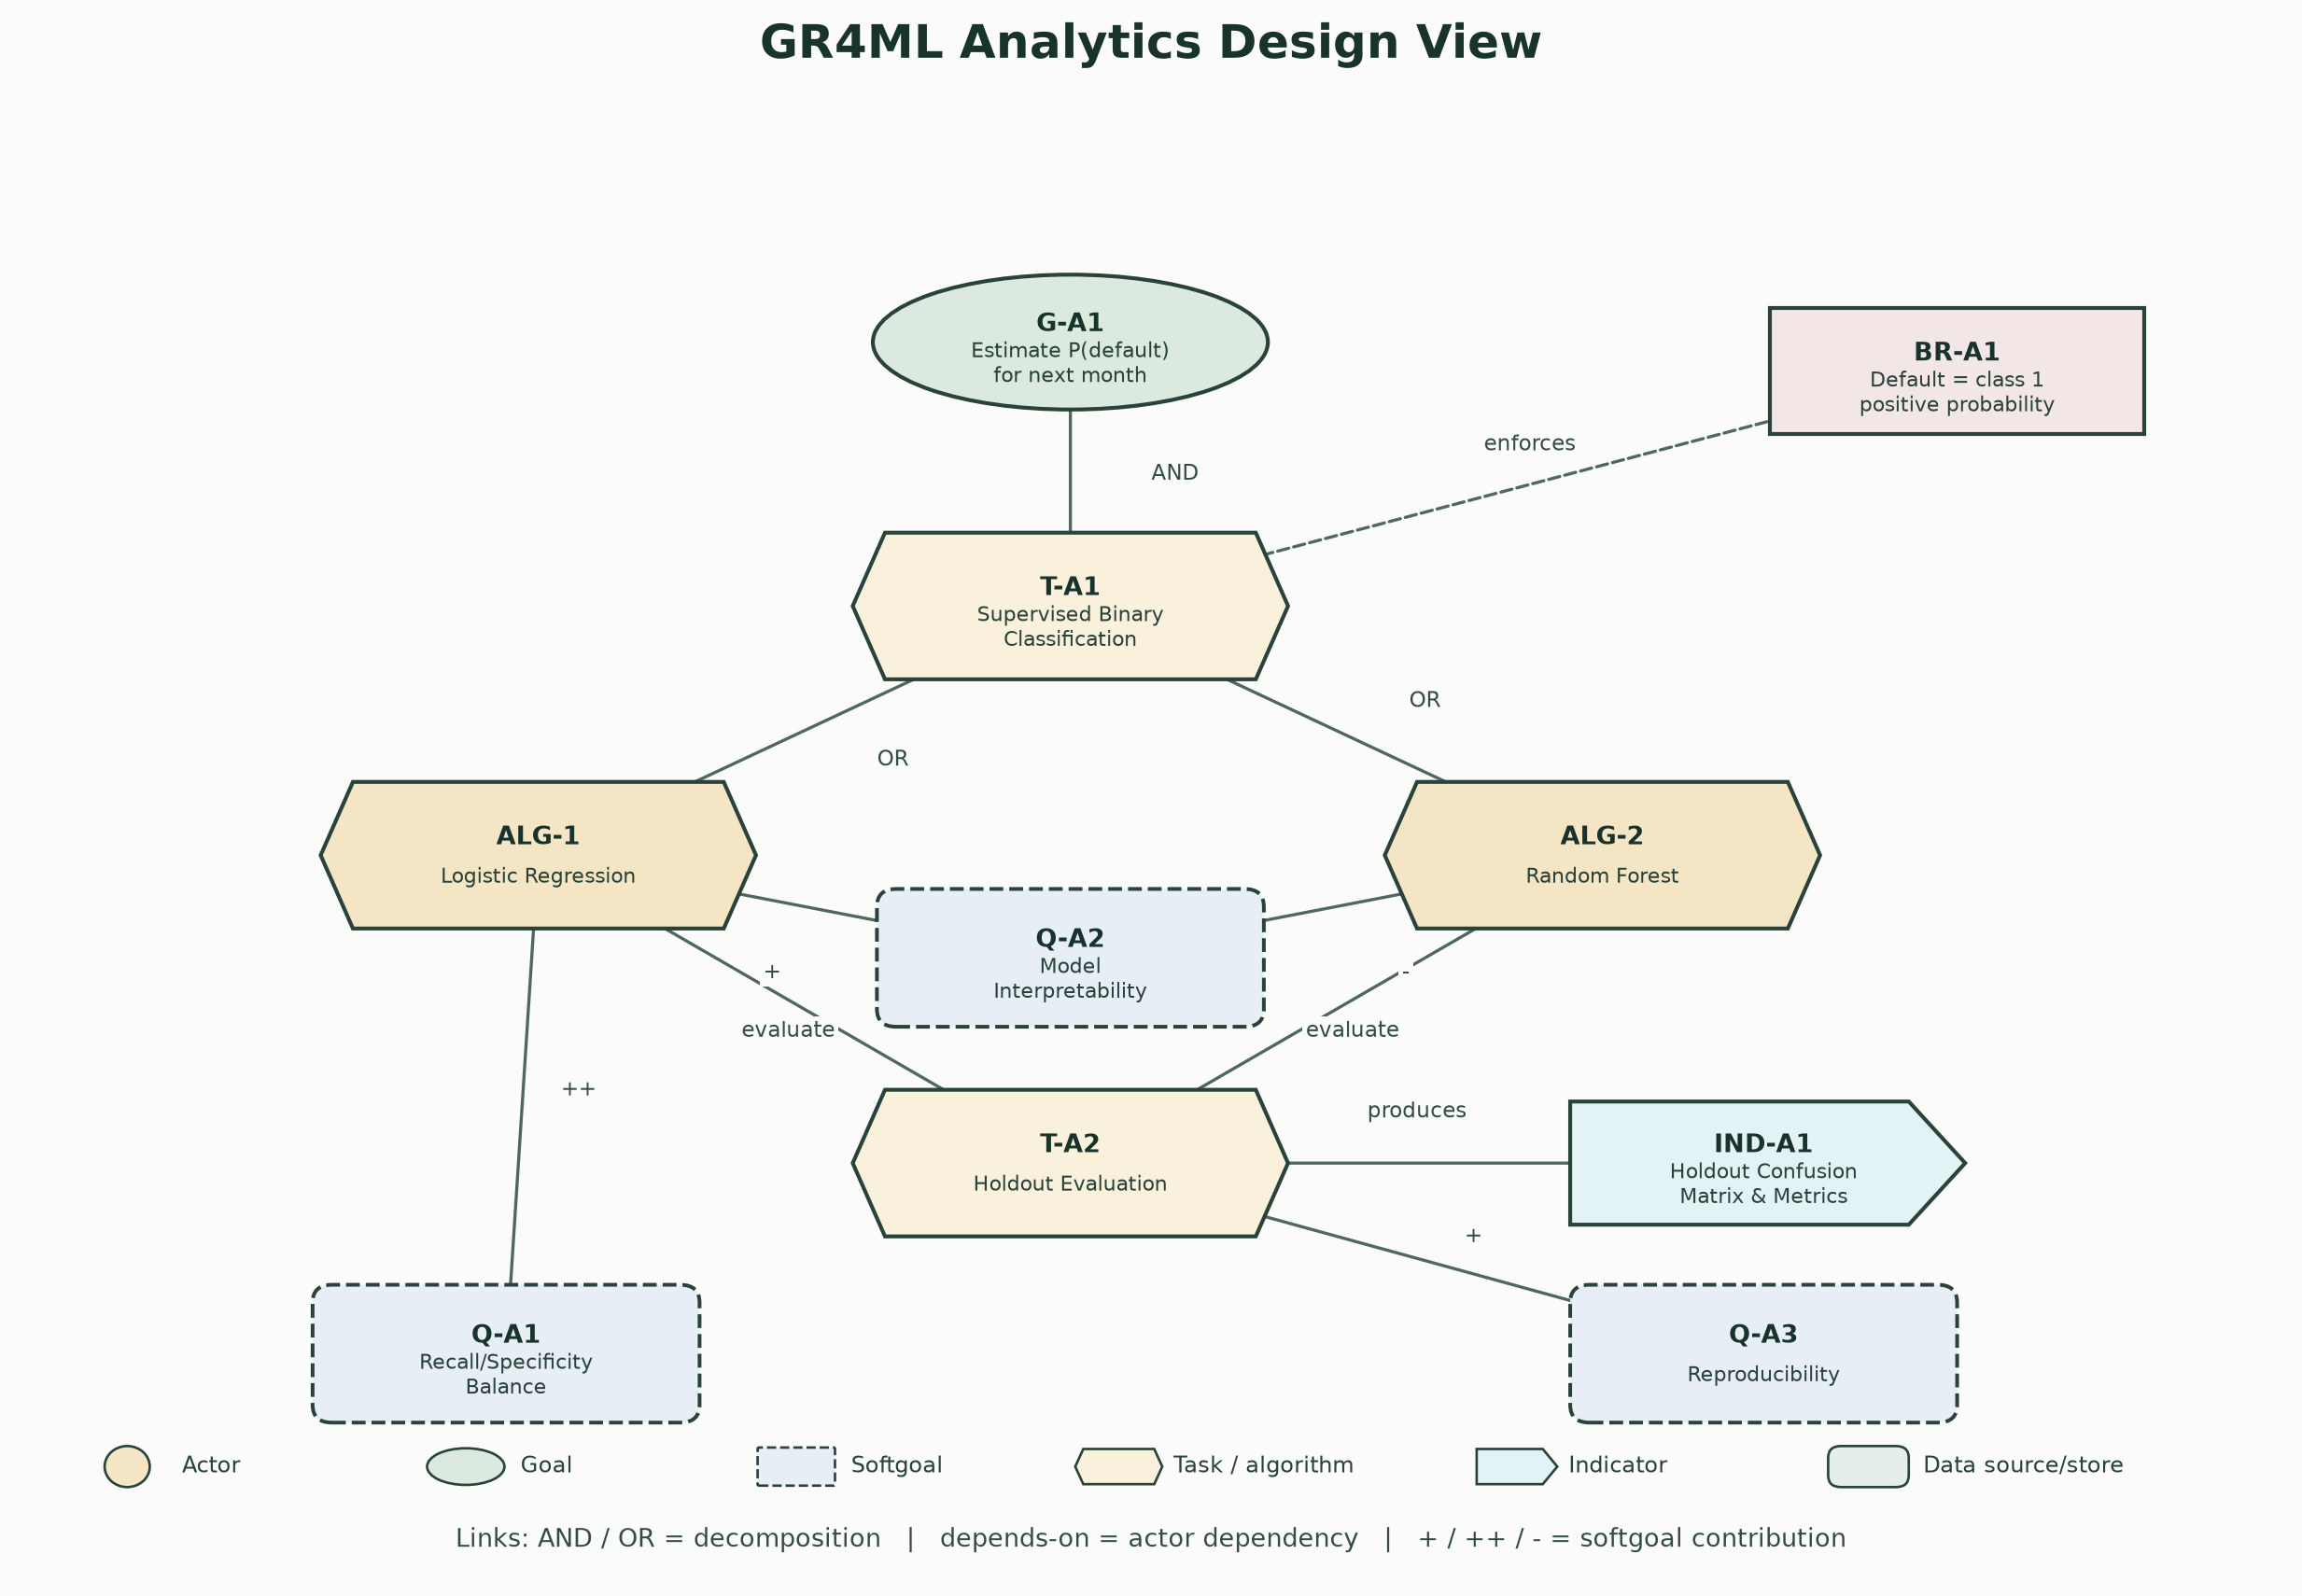

### 3.3 Data Preparation View

| Element | GR4ML statement |
|---|---|
| DS-1 | Data Source/Store: Raw UCI Credit CSV [30,000 x 24]. |
| T-D1 | Data Preparation Task: Load & Target Mapping. |
| T-D2 | Data Preparation Task: Remove ID & Protected Attributes. |
| T-D3 | Data Preparation Task: Stratified Split & Train-Only Scaling. |
| DS-2 | Data Source/Store: Clean Stratified Train/Test Split [19 features]. |
| Q-D1 | Softgoal: Schema Completeness. |
| Q-D2 | Softgoal: Zero Test Leakage. |
| BR-D1 | Map default=1 and preserve predictor names/order. |
| BR-D2 | Exclude ID/demographics from training; fit transforms on training data only. |

**Traceability:** G-B1 -> G-B2 -> (AND) G-B2a / G-B2b -> T-B1; IND-1 / IND-2 -> G-A1 -> T-A1 -> (OR) ALG-1 / ALG-2 -> T-A2 -> IND-A1; DS-1 -> T-D1 -> T-D2 -> T-D3 -> DS-2 -> T-A1. Q-D1 and Q-D2 are supported by the data-preparation controls.

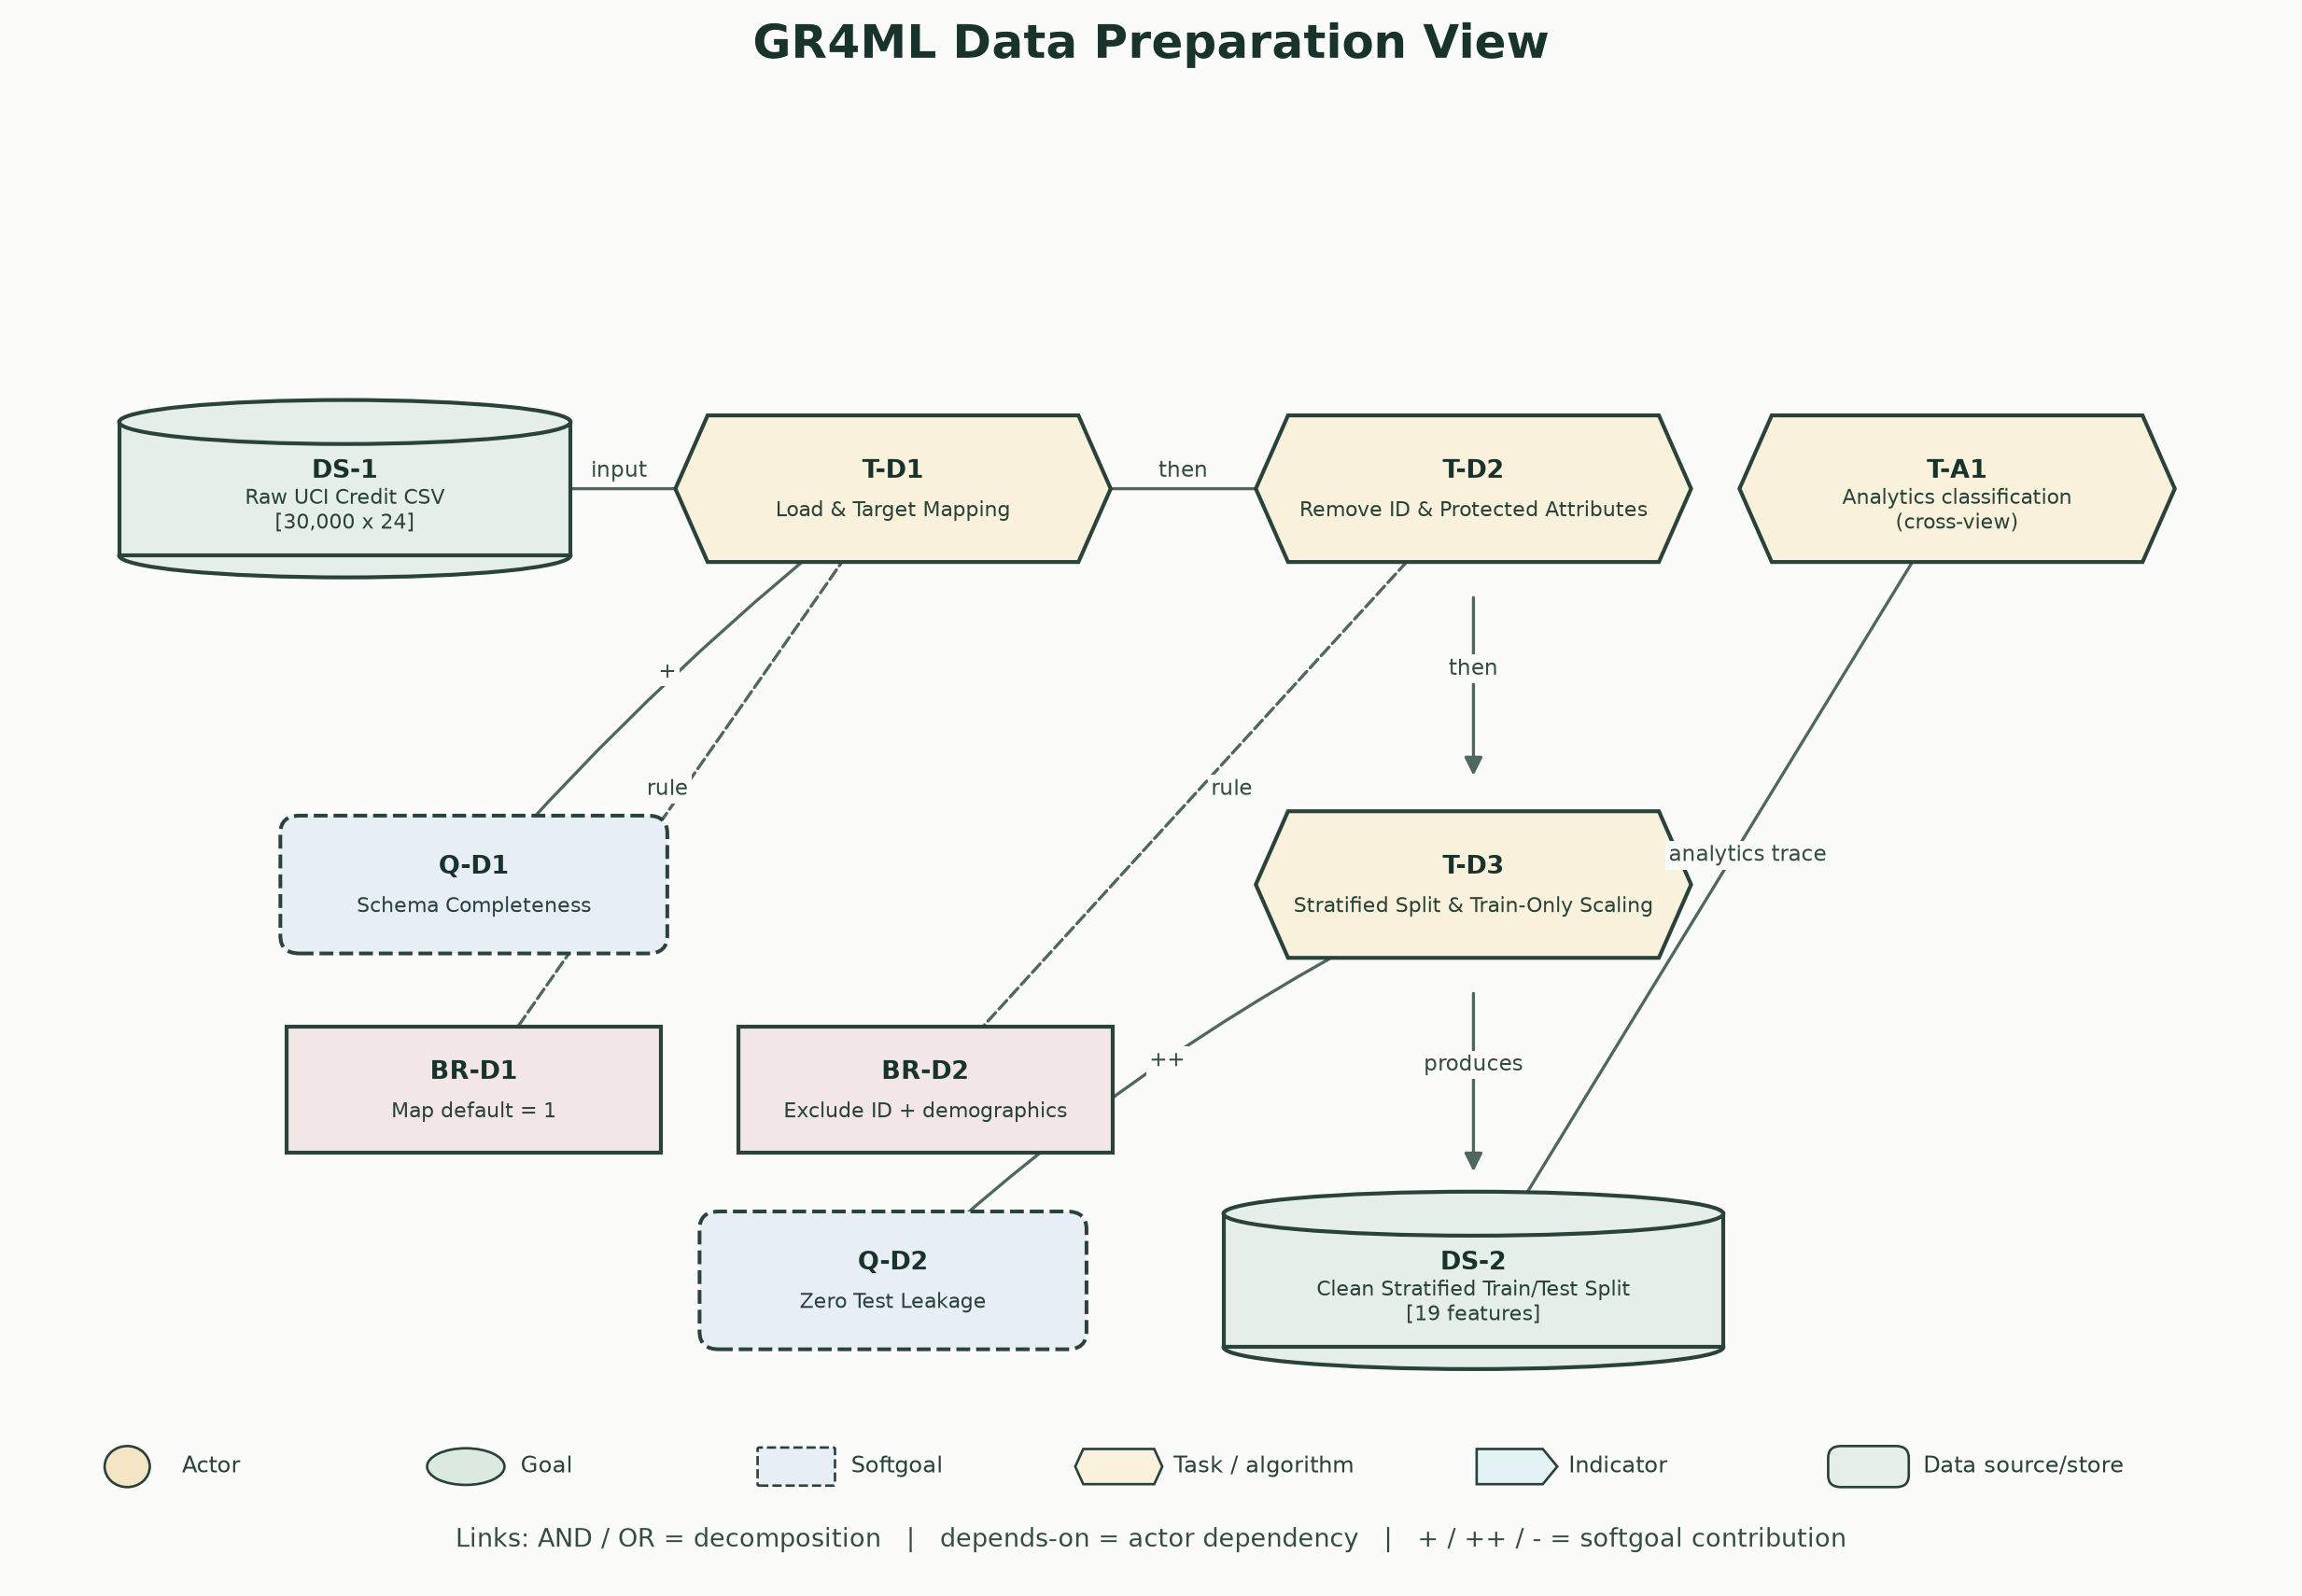


## 4. Top three quality requirements

1. **Effectiveness and decision safety:** false negatives can hide repayment risk, while false positives waste analyst capacity and may unfairly burden customers. Recall and specificity must both be measured. Release gate: each >=70% on independent later-period data, with no automated customer action. At threshold 0.50, the current random holdout does not meet both targets for either strategy; no model is presented as ready for use.
2. **Fairness:** historical lending outcomes may encode structural and policy bias. Sex, education, marital status, and age are excluded from model inputs; this alone does not remove proxy bias. Before a pilot, conduct a lawful, governed subgroup audit and block use if the relevant-group recall gap exceeds 5 percentage points or evidence is inadequate.
3. **Privacy and security:** financial account data is sensitive. The local prototype has no customer storage or external transmission and uses a de-identified public benchmark. A real system would additionally require access control, encryption, audit, retention limits, threat modeling, and regulatory review.


## 5. System Architecture and Architectural Patterns

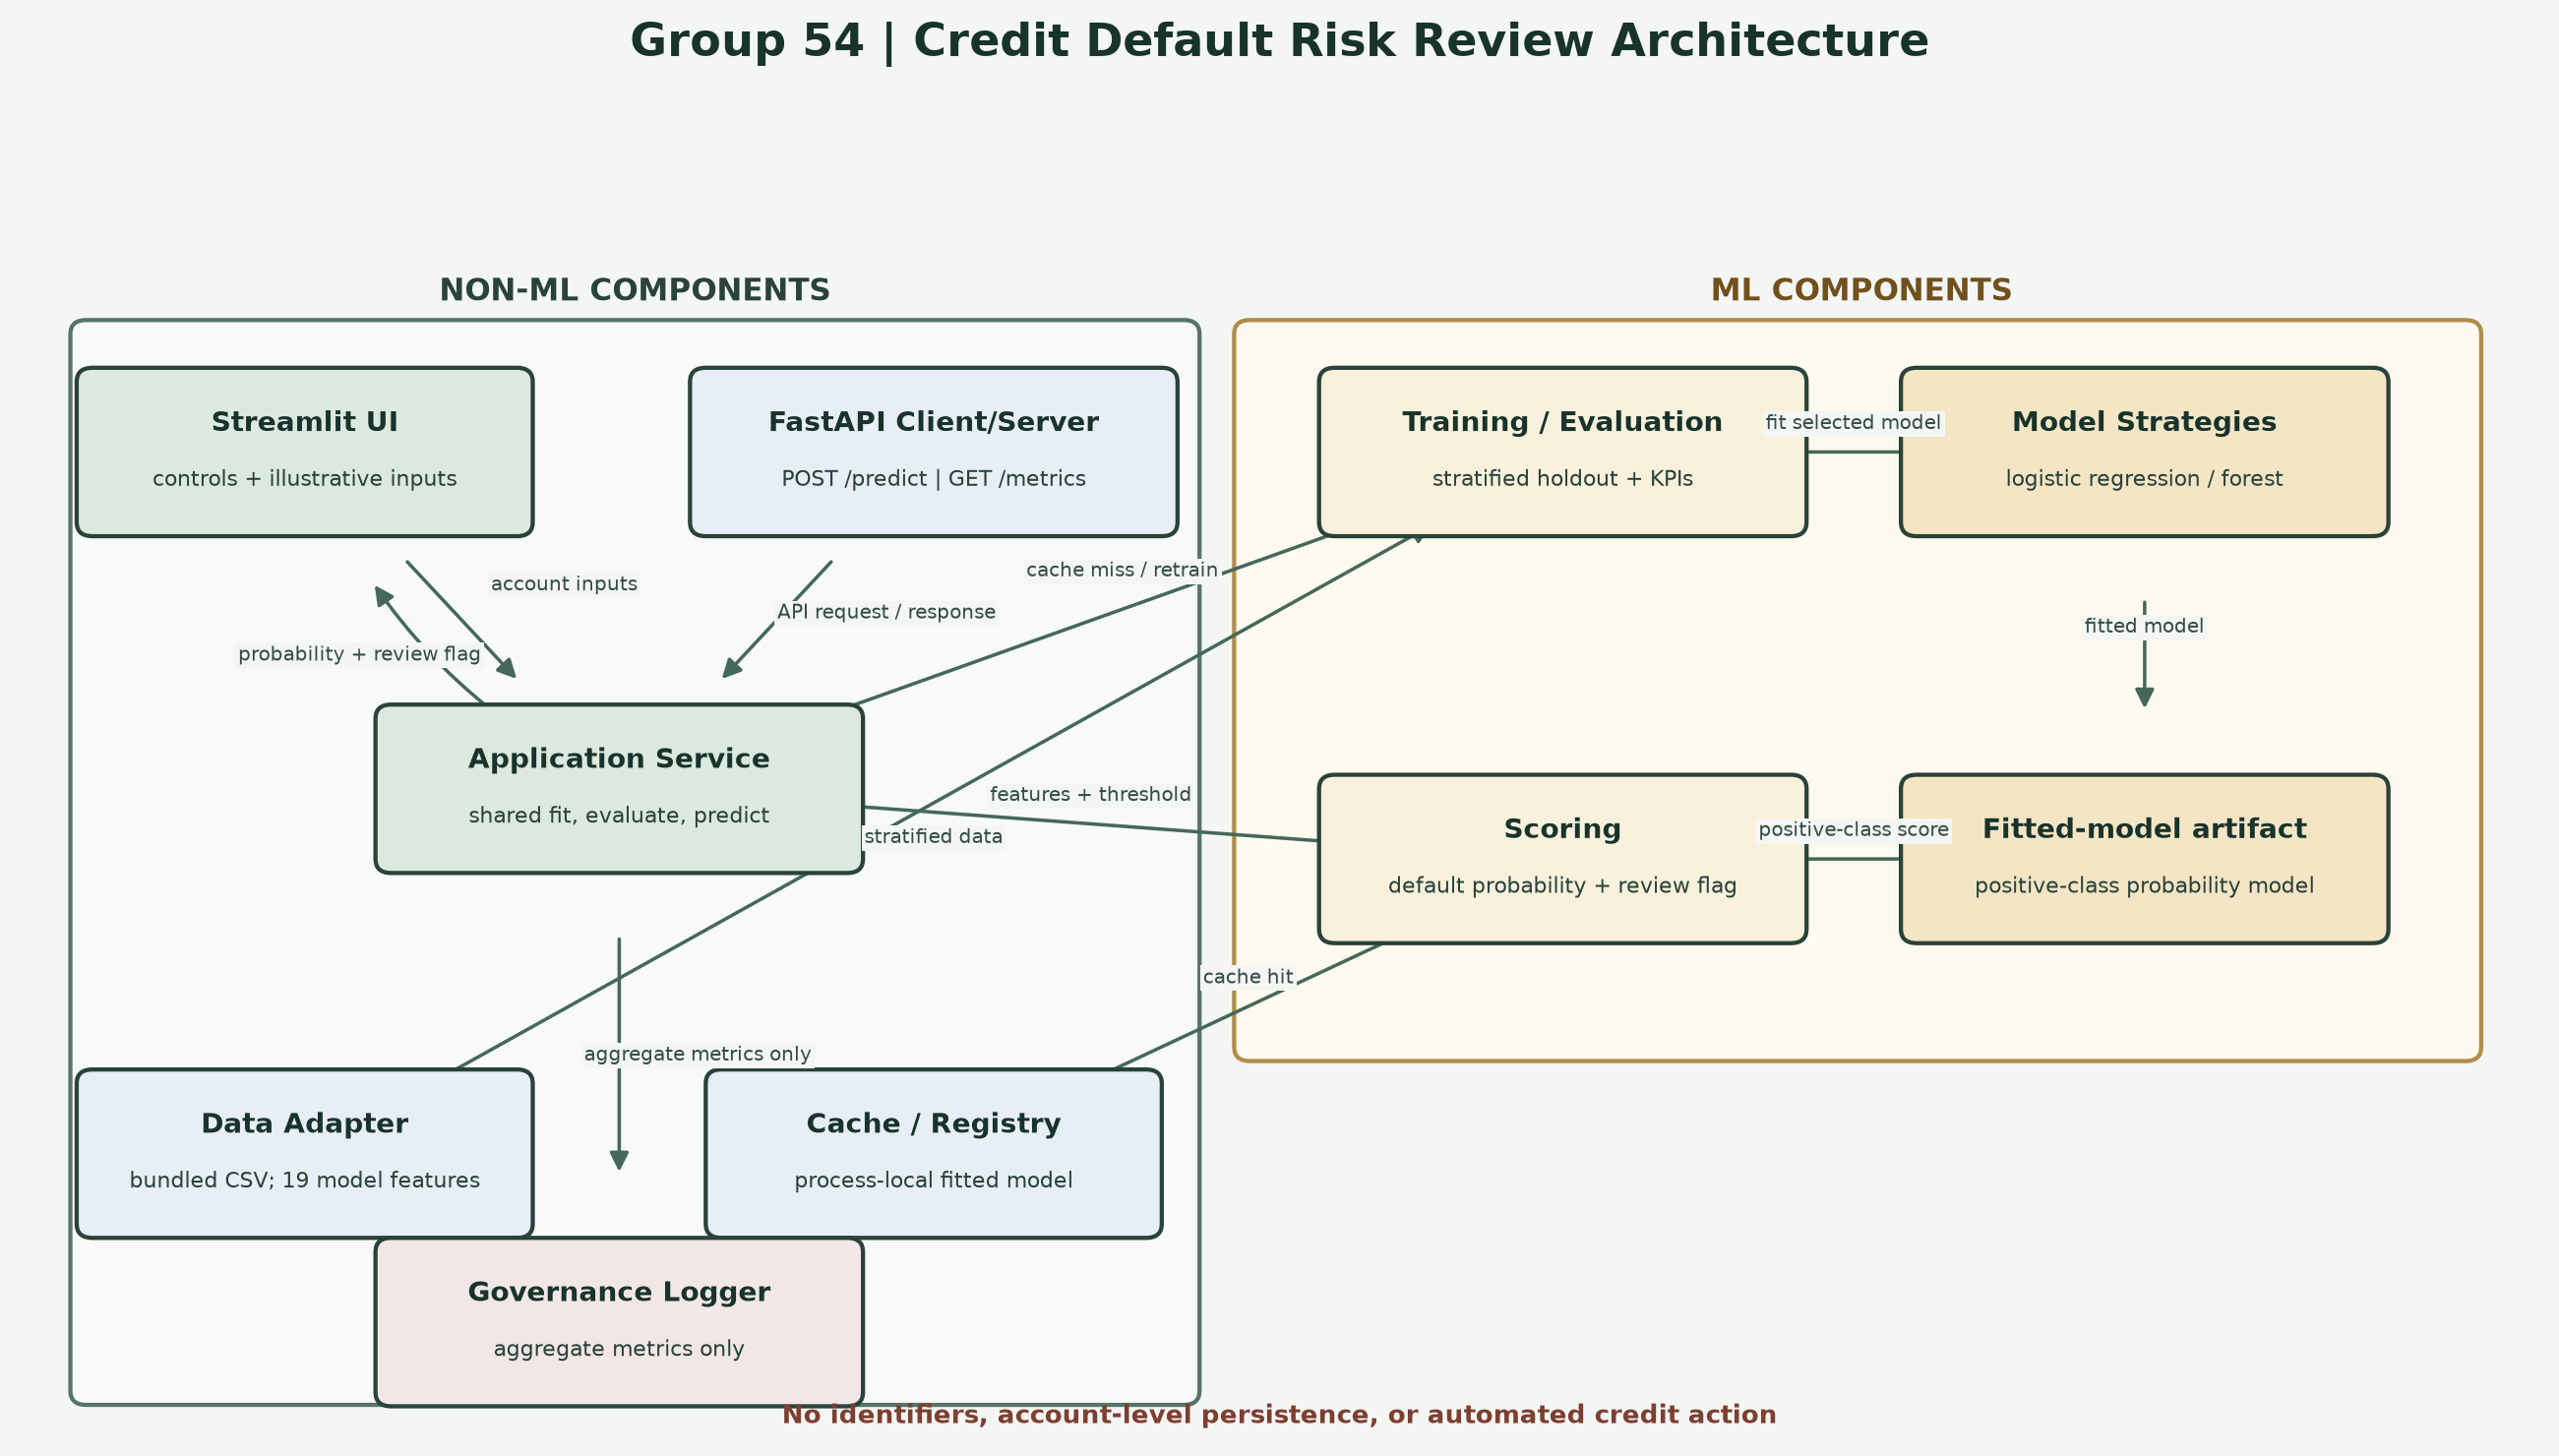

**Non-ML components:** Streamlit UI, FastAPI server, application service, cache/registry, data adapter, and governance logger. **ML components:** training/evaluation, model strategies, fitted artifact, and scoring. Streamlit remains a direct service client; FastAPI is an optional second client. Inputs and predictions are not persisted; there is no automated credit action.

### Pattern 1 - Layered Architecture

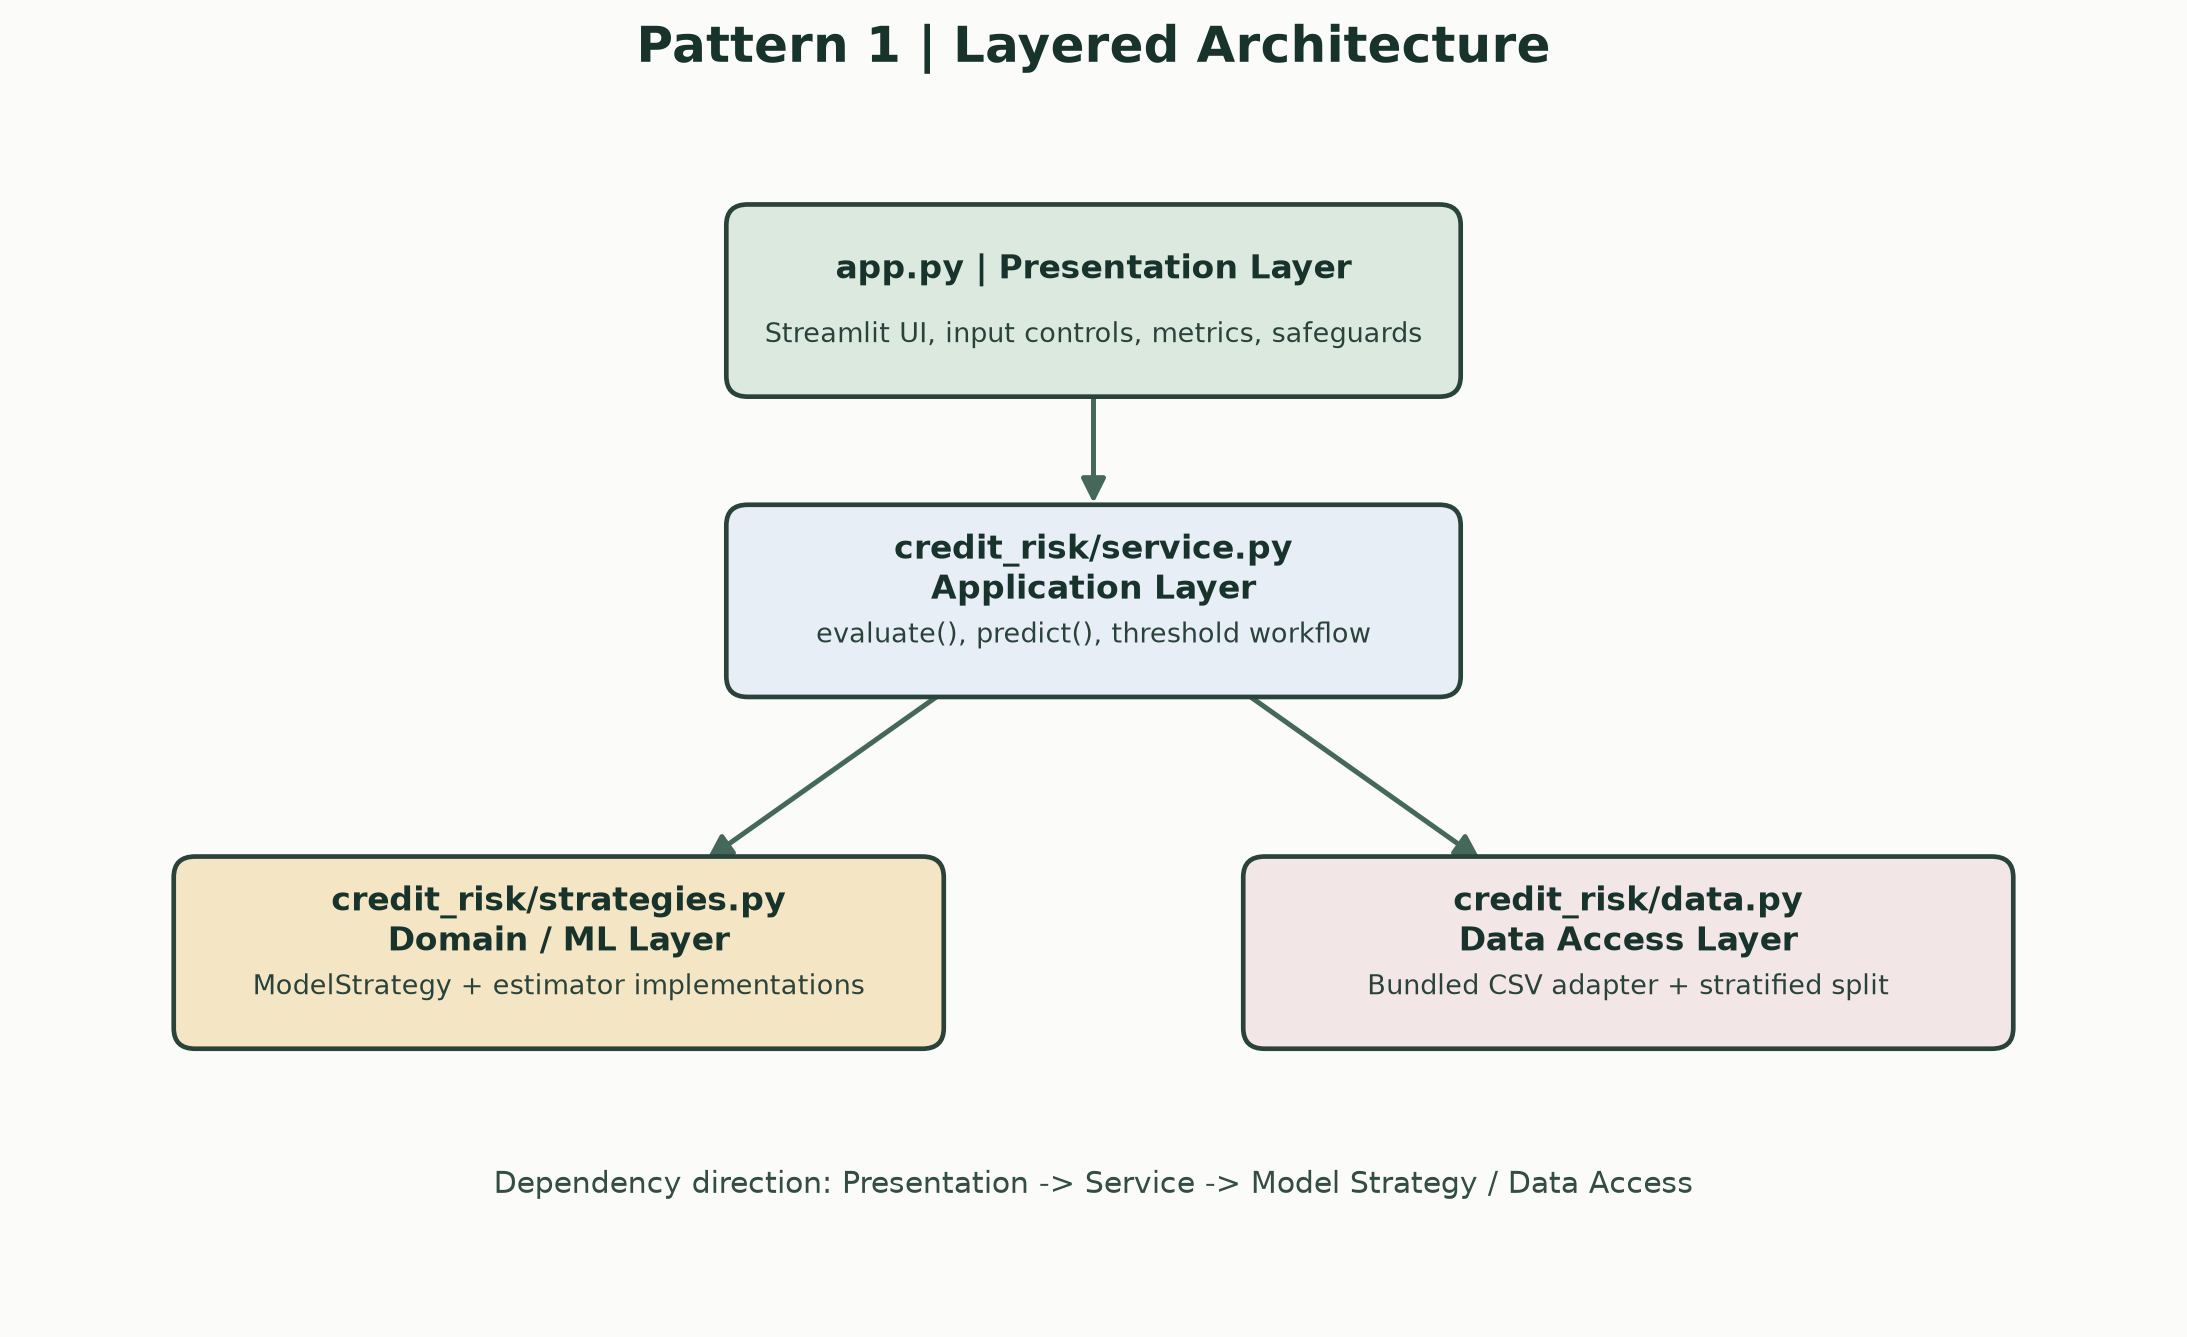

### Pattern 2 - Model-as-a-Service (Client-Server)

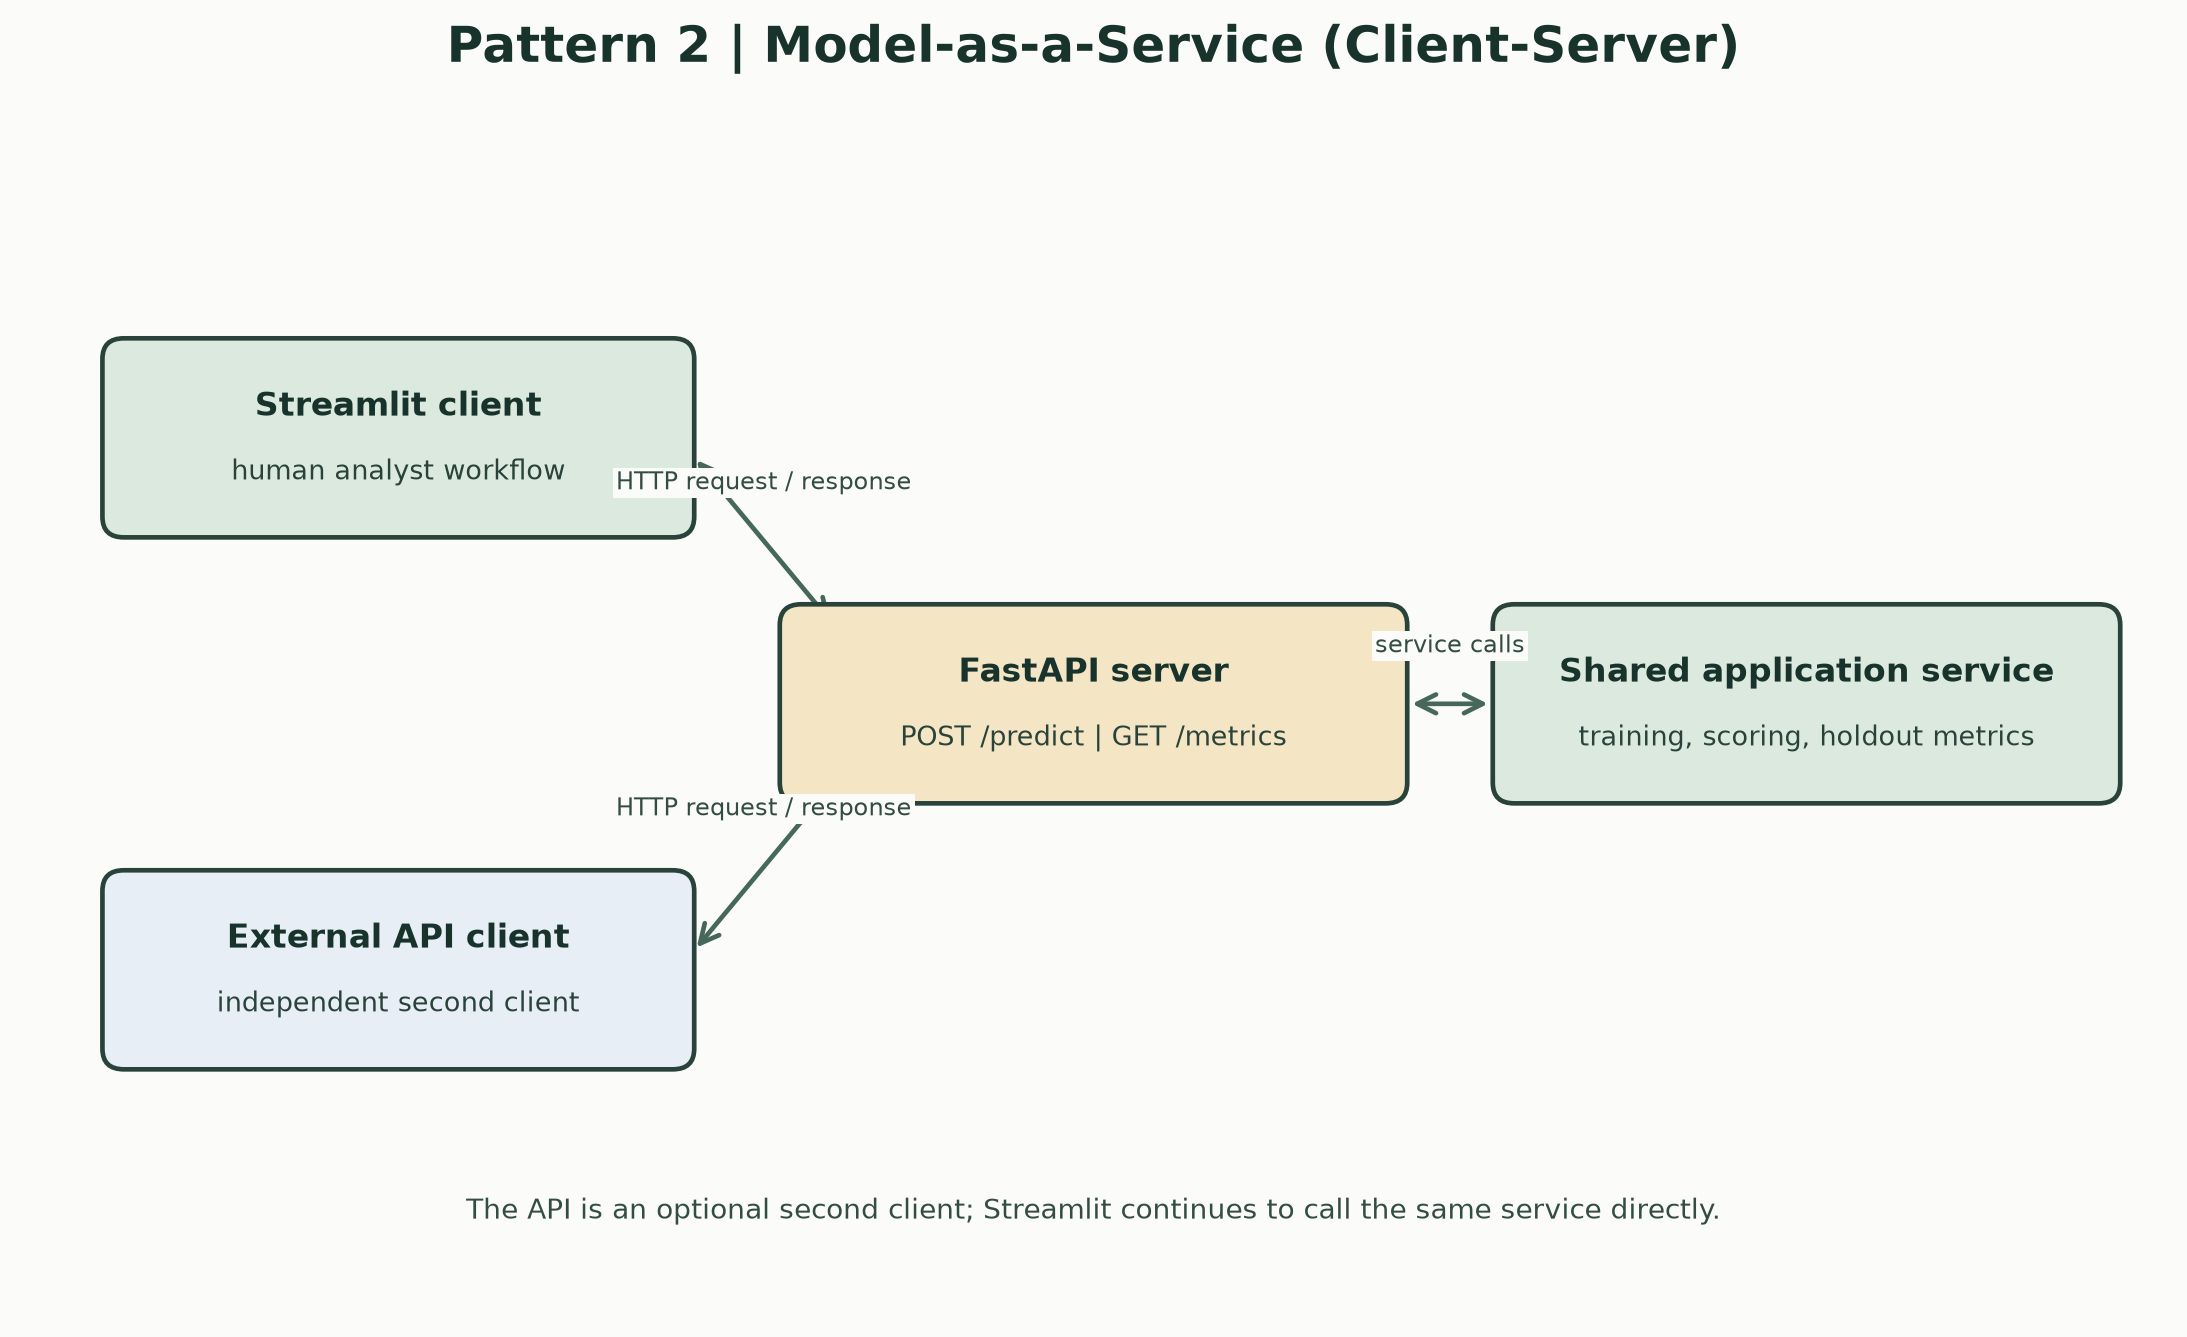

### Supporting Design Pattern - Strategy (GoF)

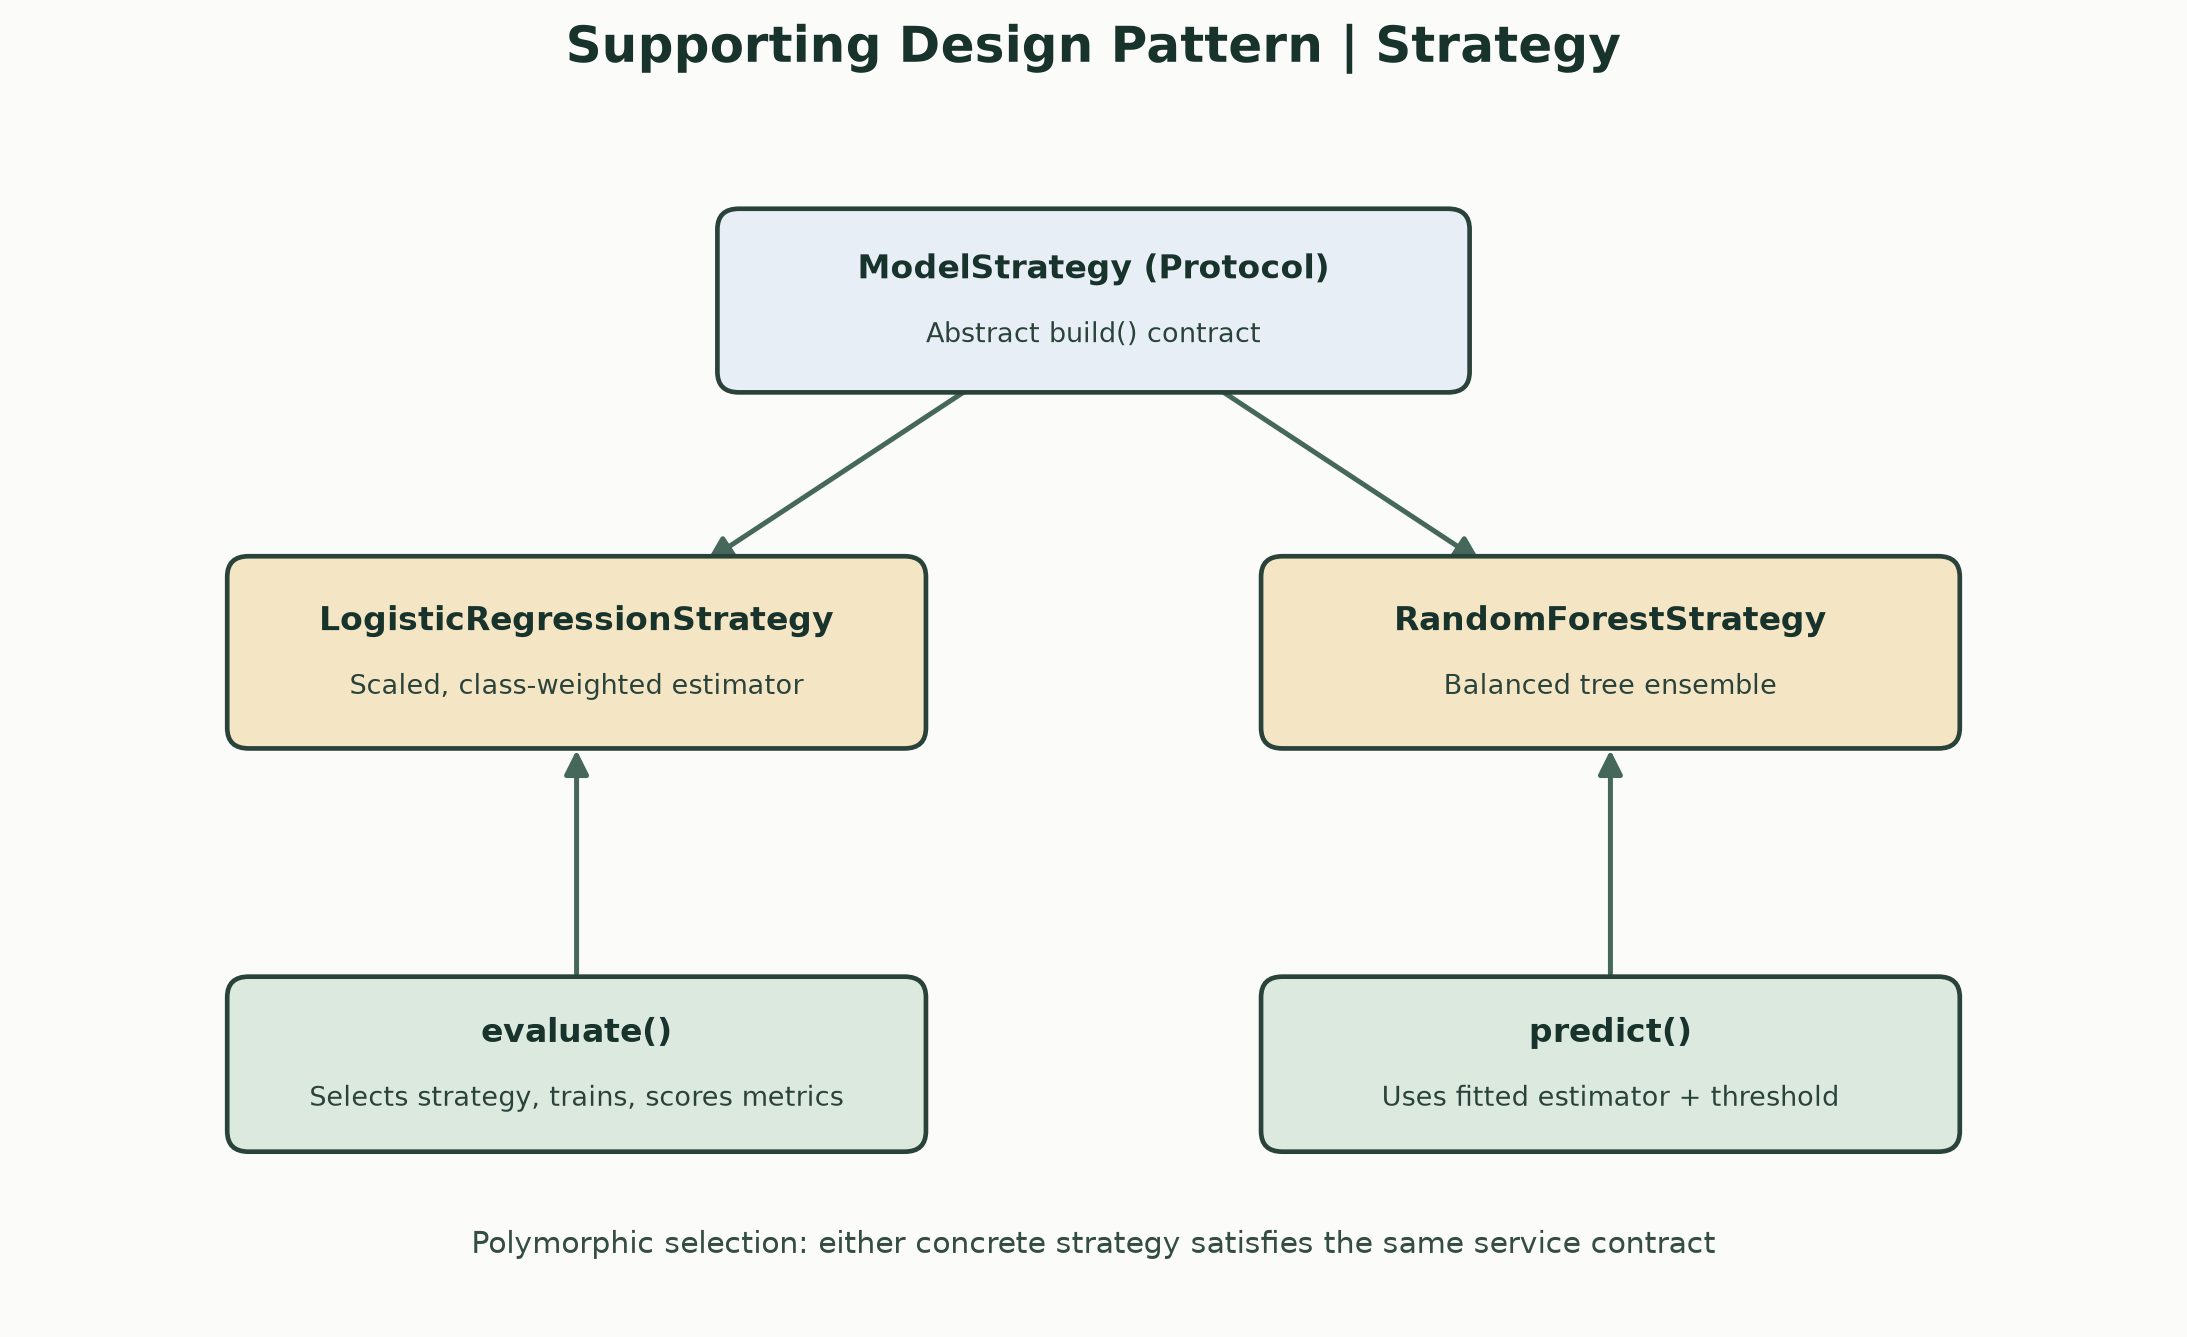

| Pattern Name | Context / Problem | Solution / Structure | Components Mapped in Code | Advantages | Trade-offs |
|---|---|---|---|---|---|
| Layered Architecture | UI, ML workflow, and data loading would otherwise be tightly coupled. | Presentation calls service; service coordinates model and data access. | `app.py` -> `credit_risk/service.py` -> `credit_risk/strategies.py` and `credit_risk/data.py`; Streamlit cache stores fitted models. | Clear responsibilities, focused tests, and independent UI/model evolution. | Additional indirection; cache is process-local and must be invalidated after model/data changes. |
| Model-as-a-Service (Client-Server) | Multiple clients need prediction without coupling to model internals. | FastAPI exposes `POST /predict` and `GET /metrics`; endpoints reuse the application service. | `api.py`, FastAPI, `credit_risk/service.py`; Streamlit remains a direct client. | Shared inference contract; independently testable HTTP interface. | Adds deployment, validation, and service availability responsibilities. |
| Supporting design pattern: Strategy (GoF) | Compare or replace estimators without duplicating evaluation and inference logic. | Common `ModelStrategy.build()` contract with interchangeable implementations. | `ModelStrategy`, both strategy classes, `get_strategy()`, `fit_model()`, `evaluate_model()`, `predict()`. | Add models without rewriting use cases. | A design pattern, not an architectural pattern; implementations must honor model contracts. |

Technologies: Python, pandas, scikit-learn Pipelines, Streamlit, matplotlib, and python-docx.


## 6. Implementation and reproducibility

    Install runtime dependencies with `python -m pip install -r requirements.txt`; start the UI with `streamlit run app.py`. Start the optional Client-Server API with `uvicorn api:app --reload`. Install verification tools from `requirements-dev.txt`; run tests with `pytest`.

    The bundled CSV keeps runs independent of network access. The Streamlit interface selects a strategy and threshold, displays held-out metrics, and exposes six illustrative account controls; the other 13 model inputs use dataset medians. These controls are not live customer inputs.

    **Safeguard:** this is an educational prototype only, not for credit approval, pricing, collections, adverse action, or other real customer decisions.


In [1]:
from credit_risk.data import load_data, split_data
from credit_risk.service import evaluate_model, fit_model, predict
from credit_risk.strategies import STRATEGIES, get_strategy

features, target = load_data()
print(f"Rows: {len(features)} | model features: {features.shape[1]} | defaults: {int(target.sum())}")
print("Split sizes:", [len(part) for part in split_data()])
print("Excluded model inputs: ID, SEX, EDUCATION, MARRIAGE, AGE")

Rows: 30000 | model features: 19 | defaults: 6636
Split sizes: [24000, 6000, 24000, 6000]
Excluded model inputs: ID, SEX, EDUCATION, MARRIAGE, AGE


## 7. Holdout metrics and threshold sweep

    The following sweep computes recall, specificity, and precision at thresholds 0.30 to 0.60 in 0.05 steps for both strategies. Both >=70% targets must hold at the same threshold to pass.
    

In [2]:
results = {}
for name in STRATEGIES:
    model = fit_model(get_strategy(name))
    metrics = evaluate_model(model)
    results[name] = metrics
    print(name, {metric: round(float(metrics[metric]), 4) for metric in
                 ("recall", "specificity", "precision", "accuracy")})

Logistic regression {'recall': 0.6285, 'specificity': 0.6869, 'precision': 0.3631, 'accuracy': 0.674}


Random forest {'recall': 0.5961, 'specificity': 0.8209, 'precision': 0.4859, 'accuracy': 0.7712}


In [3]:
import pandas as pd

threshold_rows = []
for name in STRATEGIES:
    model = fit_model(get_strategy(name))
    for threshold in [round(0.30 + 0.05 * i, 2) for i in range(7)]:
        metrics = evaluate_model(model, threshold)
        threshold_rows.append({
            "strategy": name,
            "threshold": threshold,
            "recall": metrics["recall"],
            "specificity": metrics["specificity"],
            "precision": metrics["precision"],
        })
sweep = pd.DataFrame(threshold_rows)
display(sweep.style.format({"threshold": "{:.2f}", "recall": "{:.2%}",
                            "specificity": "{:.2%}", "precision": "{:.2%}"}))
both_targets = sweep[(sweep["recall"] >= 0.70) & (sweep["specificity"] >= 0.70)]
print("A tested threshold meets both >=70% targets:", not both_targets.empty)
if both_targets.empty:
    print("No tested strategy/threshold pair meets both targets on this fixed holdout.")
else:
    print(both_targets[["strategy", "threshold"]].to_string(index=False))

,strategy,threshold,recall,specificity,precision
0,Logistic regression,0.30,89.98%,21.27%,24.50%
1,Logistic regression,0.35,82.22%,32.48%,25.69%
2,Logistic regression,0.40,77.09%,40.85%,27.01%
3,Logistic regression,0.45,71.36%,51.23%,29.36%
4,Logistic regression,0.50,62.85%,68.69%,36.31%
5,Logistic regression,0.55,48.83%,86.52%,50.70%
6,Logistic regression,0.60,42.58%,90.82%,56.84%
7,Random forest,0.30,82.89%,48.96%,31.56%
8,Random forest,0.35,75.73%,61.52%,35.85%
9,Random forest,0.40,68.43%,71.09%,40.19%


A tested threshold meets both >=70% targets: False
No tested strategy/threshold pair meets both targets on this fixed holdout.


## 8. Audit-only subgroup recall

SEX and AGE are loaded separately for the same held-out row indices; they are not model features. The maximum subgroup recall gap is compared with the <=5 percentage-point goal. This is a coursework audit, not a governed fairness assessment.


In [4]:
from credit_risk.fairness import audit_recall_by_group

fairness_results = {}
for name in STRATEGIES:
    audit = audit_recall_by_group(fit_model(get_strategy(name)))
    fairness_results[name] = audit
    print(name, audit["recall_by_group"])
    print(f"Maximum recall gap: {audit['max_gap_pp']:.2f} percentage points; "
          f"{'MEETS' if audit['meets_target'] else 'DOES NOT MEET'} <=5pp target")

Logistic regression {'SEX': {'1': 0.6524064171122995, '2': 0.6109660574412533}, 'AGE band': {'<=29': 0.6885245901639344, '30-39': 0.6070640176600441, '40-49': 0.5801282051282052, '50-59': 0.6339285714285714, '60+': 0.5652173913043478}}
Maximum recall gap: 12.33 percentage points; DOES NOT MEET <=5pp target


Random forest {'SEX': {'1': 0.5953654188948306, '2': 0.5966057441253264}, 'AGE band': {'<=29': 0.6370023419203747, '30-39': 0.5783664459161147, '40-49': 0.5737179487179487, '50-59': 0.5892857142857143, '60+': 0.5217391304347826}}
Maximum recall gap: 11.53 percentage points; DOES NOT MEET <=5pp target


## 9. Prediction and automated verification

The test cell exercises the same data, split, target, probability, threshold, strategy, fairness-input, and API conditions documented in the report.


In [5]:
model = fit_model(get_strategy("Logistic regression"))
example = features.median().to_frame().T
result = predict(model, example, threshold=0.50)
print({key: round(value, 4) if isinstance(value, float) else value
       for key, value in result.items()})
print("Educational example only; not a customer-level financial decision.")

{'default_probability': 0.5026, 'flag_for_review': True, 'threshold': 0.5}
Educational example only; not a customer-level financial decision.


In [6]:
import pytest

exit_code = pytest.main(["-q", "tests/test_credit_risk.py"])
assert int(exit_code) == 0
print("7 tests passed")

.

.

.

.

.

.

.

                                                                  [100%]


============================== warnings summary ===============================
.venv\Lib\site-packages\fastapi\testclient.py:1
  C:\BITS\Sem-3\Software_Engineering\Assignments\Assignment_1_Group_54\.venv\Lib\site-packages\fastapi\testclient.py:1: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
    from starlette.testclient import TestClient as TestClient  # noqa

-- Docs: https://docs.pytest.org/en/stable/how-to/capture-warnings.html
7 passed, 1 warning in 7.16s


7 tests passed


## 10. Appendix - Complete Source Code

The complete implementation and tests are reproduced below so the notebook can be reviewed alongside the submission bundle.

### `credit_risk/data.py`

```python
"""Credit-default dataset access and deterministic evaluation split."""

from pathlib import Path

import pandas as pd
from sklearn.model_selection import train_test_split


RANDOM_STATE = 42
DATA_PATH = Path(__file__).resolve().parents[1] / "submission_assets" / "credit_default.csv"
EXCLUDED_FEATURES = ["SEX", "EDUCATION", "MARRIAGE", "AGE"]


def load_data():
    """Return credit-account features and a target where 1 means default next month."""
    dataset = pd.read_csv(DATA_PATH)
    target = dataset.pop("default").astype(int).rename("default")
    features = dataset.drop(columns=EXCLUDED_FEATURES)
    return features, target


def split_data(test_size=0.2):
    features, target = load_data()
    return train_test_split(
        features,
        target,
        test_size=test_size,
        random_state=RANDOM_STATE,
        stratify=target,
    )
```

### `credit_risk/strategies.py`

```python
"""Interchangeable model strategies used by the application service."""

from typing import Protocol

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


class ModelStrategy(Protocol):
    name: str

    def build(self):
        """Create an unfitted estimator."""


class LogisticRegressionStrategy:
    name = "Logistic regression"

    def build(self):
        return make_pipeline(
            StandardScaler(),
            LogisticRegression(class_weight="balanced", max_iter=1500, random_state=42),
        )


class RandomForestStrategy:
    name = "Random forest"

    def build(self):
        return RandomForestClassifier(
            n_estimators=160,
            class_weight="balanced",
            min_samples_leaf=10,
            n_jobs=1,
            random_state=42,
        )


STRATEGIES = {
    LogisticRegressionStrategy.name: LogisticRegressionStrategy,
    RandomForestStrategy.name: RandomForestStrategy,
}


def get_strategy(name):
    try:
        return STRATEGIES[name]()
    except KeyError as error:
        raise ValueError(f"Unknown model strategy: {name}") from error
```

### `credit_risk/service.py`

```python
"""Application-level training, evaluation, and inference operations."""

import logging

from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score

from .data import split_data
from .strategies import LogisticRegressionStrategy


DEFAULT_THRESHOLD = 0.5
LOGGER = logging.getLogger(__name__)


def default_probability(model, features):
    default_index = list(model.classes_).index(1)
    return model.predict_proba(features)[:, default_index]


def fit_model(strategy=None):
    strategy = strategy or LogisticRegressionStrategy()
    x_train, _, y_train, _ = split_data()
    model = strategy.build()
    model.fit(x_train, y_train)
    return model


def evaluate_model(model, threshold=DEFAULT_THRESHOLD, split=None):
    _, x_test, _, y_test = split if split is not None else split_data()
    probabilities = default_probability(model, x_test)
    predictions = (probabilities >= threshold).astype(int)
    true_negative, false_positive, false_negative, true_positive = confusion_matrix(
        y_test, predictions, labels=[0, 1]
    ).ravel()
    metrics = {
        "accuracy": accuracy_score(y_test, predictions),
        "recall": recall_score(y_test, predictions, zero_division=0),
        "specificity": true_negative / (true_negative + false_positive),
        "precision": precision_score(y_test, predictions, zero_division=0),
        "true_negative": int(true_negative),
        "false_positive": int(false_positive),
        "false_negative": int(false_negative),
        "true_positive": int(true_positive),
        "test_size": len(y_test),
    }
    LOGGER.info(
        "Model evaluation: estimator=%s threshold=%.2f metrics=%s",
        type(model).__name__, threshold, metrics,
    )
    return metrics


def evaluate(strategy=None, threshold=DEFAULT_THRESHOLD):
    model = fit_model(strategy)
    metrics = evaluate_model(model, threshold)
    return model, metrics


def predict(model, features, threshold=DEFAULT_THRESHOLD):
    probability = float(default_probability(model, features)[0])
    return {
        "default_probability": probability,
        "flag_for_review": probability >= threshold,
        "threshold": threshold,
    }
```

### `credit_risk/fairness.py`

```python
"""Coursework subgroup recall audit using demographics excluded from modeling."""

import pandas as pd
from sklearn.metrics import recall_score

from .data import DATA_PATH, split_data
from .service import default_probability


def audit_recall_by_group(model, threshold=0.5):
    """Return holdout recall by sex and age band; audit fields never enter the model."""
    _, x_test, _, y_test = split_data()
    audit = pd.read_csv(DATA_PATH, usecols=["SEX", "AGE"]).loc[x_test.index]
    predictions = (default_probability(model, x_test) >= threshold).astype(int)
    rows = pd.DataFrame({"target": y_test, "prediction": predictions}, index=x_test.index)
    rows["SEX"] = audit["SEX"]
    rows["AGE band"] = pd.cut(
        audit["AGE"],
        bins=[0, 29, 39, 49, 59, float("inf")],
        labels=["<=29", "30-39", "40-49", "50-59", "60+"],
    )

    recall_by_group = {}
    for column in ("SEX", "AGE band"):
        group_scores = {}
        for group, values in rows.groupby(column, observed=True):
            group_scores[str(group)] = float(
                recall_score(values["target"], values["prediction"], zero_division=0)
            )
        recall_by_group[column] = group_scores

    gaps = [
        max(scores.values()) - min(scores.values())
        for scores in recall_by_group.values()
        if scores
    ]
    return {
        "recall_by_group": recall_by_group,
        "max_gap_pp": max(gaps, default=0.0) * 100,
        "target_pp": 5.0,
        "meets_target": max(gaps, default=0.0) * 100 <= 5.0,
    }
```

### `app.py`

```python
"""Streamlit user interface for credit-default risk review."""

import streamlit as st

from credit_risk.data import load_data, split_data
from credit_risk.service import evaluate_model, fit_model as train_model, predict
from credit_risk.strategies import STRATEGIES, get_strategy


st.set_page_config(page_title="Credit Default Risk Review | Group 54", page_icon="$", layout="wide")
st.title("Credit Default Risk Review")
st.caption("A financial-risk coursework prototype for analyst review, not an automated credit decision.")


@st.cache_resource
def fit_model(model_name):
    return train_model(get_strategy(model_name))


@st.cache_data
def load_app_data():
    return load_data()


@st.cache_data
def load_evaluation_split():
    return split_data()


features, _ = load_app_data()
evaluation_split = load_evaluation_split()
model_name = st.sidebar.selectbox("Model strategy", list(STRATEGIES))
threshold = st.sidebar.slider("Review threshold", 0.10, 0.90, 0.50, 0.01)
model = fit_model(model_name)
metrics = evaluate_model(model, threshold, evaluation_split)

st.subheader("Held-out evaluation")
metric_columns = st.columns(4)
for column, label, key in zip(
    metric_columns,
    ["Default recall", "Specificity", "Precision", "Accuracy"],
    ["recall", "specificity", "precision", "accuracy"],
):
    column.metric(label, f"{metrics[key]:.1%}")
st.caption(
    f"Stratified 80/20 split; {metrics['test_size']} held-out records. "
    "Historical retrospective results; not evidence of future portfolio or customer-level performance."
)

st.subheader("Account review")
st.write("Adjust six account indicators. The other 13 model inputs are held at dataset medians.")
selected_features = [
    "LIMIT_BAL",
    "PAY_0",
    "PAY_2",
    "BILL_AMT1",
    "PAY_AMT1",
    "BILL_AMT2",
]
case = features.median().to_frame().T.copy()
input_columns = st.columns(3)
for index, feature_name in enumerate(selected_features):
    with input_columns[index % 3]:
        low = float(features[feature_name].quantile(0.05))
        high = float(features[feature_name].quantile(0.95))
        default = float(features[feature_name].median())
        if feature_name in {"PAY_0", "PAY_2"}:
            low, high, default = int(low), int(high), int(round(default))
            case.loc[0, feature_name] = st.slider(
                feature_name, low, high, default, 1
            )
        else:
            step = float(max(100, round((high - low) / 1000 / 100) * 100))
            low = float(round(low / step) * step)
            high = float(round(high / step) * step)
            default = float(min(max(round(default / step) * step, low), high))
            case.loc[0, feature_name] = st.slider(
                feature_name, low, high, default, step, format="%.0f"
            )

result = predict(model, case, threshold)
left, right = st.columns([2, 1])
with left:
    st.metric("Model-estimated next-month default risk", f"{result['default_probability']:.1%}")
    st.progress(result["default_probability"])
with right:
    if result["flag_for_review"]:
        st.error("Flagged for credit-risk analyst review")
    else:
        st.success("Below the selected review threshold")

st.warning(
    "Educational demonstration only. Do not use this score for credit approval, pricing, "
    "collections, or other customer-level decisions. Inputs are illustrative controls; "
    "independent validation, fairness review, and qualified oversight are required."
)
```

### `api.py`

```python
"""FastAPI client/server interface for the shared credit-risk service."""

from functools import lru_cache

import pandas as pd
from fastapi import FastAPI, HTTPException, Query
from pydantic import BaseModel, Field

from credit_risk.data import load_data
from credit_risk.service import evaluate_model, fit_model
from credit_risk.strategies import STRATEGIES, get_strategy


app = FastAPI(
    title="Group 54 Credit Default Risk API",
    description="Educational prototype only; not for real credit decisions.",
)


class PredictionRequest(BaseModel):
    strategy: str = "Logistic regression"
    features: dict[str, float]
    threshold: float = Field(default=0.5, ge=0.0, le=1.0)


@lru_cache(maxsize=None)
def get_fitted_model(strategy_name):
    return fit_model(get_strategy(strategy_name))


def checked_model(strategy_name):
    try:
        return get_fitted_model(strategy_name)
    except ValueError as error:
        raise HTTPException(status_code=422, detail=str(error)) from error


@app.post("/predict")
def predict_endpoint(request: PredictionRequest):
    model = checked_model(request.strategy)
    columns = load_data()[0].columns
    missing = set(columns) - set(request.features)
    extra = set(request.features) - set(columns)
    if missing or extra:
        raise HTTPException(
            status_code=422,
            detail={"missing_features": sorted(missing), "unknown_features": sorted(extra)},
        )
    values = pd.DataFrame([[request.features[name] for name in columns]], columns=columns)
    probability = float(model.predict_proba(values)[0][list(model.classes_).index(1)])
    return {
        "default_probability": probability,
        "flag_for_review": probability >= request.threshold,
    }


@app.get("/metrics")
def metrics_endpoint(
    strategy: str = Query(default="Logistic regression"),
    threshold: float = Query(default=0.5, ge=0.0, le=1.0),
):
    model = checked_model(strategy)
    return {"strategy": strategy, "threshold": threshold, **evaluate_model(model, threshold)}


@app.get("/health")
def health_endpoint():
    return {"status": "ok", "strategies": list(STRATEGIES)}
```

### `tests/test_credit_risk.py`

```python
import numpy as np
import pandas as pd
import pytest
from fastapi.testclient import TestClient

from api import app
from credit_risk.data import DATA_PATH, EXCLUDED_FEATURES, load_data, split_data
from credit_risk.fairness import audit_recall_by_group
from credit_risk.service import fit_model, predict
from credit_risk.strategies import STRATEGIES, get_strategy


client = TestClient(app)


def test_dataset_schema_target_and_demographic_exclusions():
    features, target = load_data()
    raw = pd.read_csv(DATA_PATH)
    assert len(features) == 30_000
    assert features.shape[1] == 19
    assert not set(EXCLUDED_FEATURES).intersection(features.columns)
    assert not {"SEX", "EDUCATION", "MARRIAGE", "AGE"}.intersection(features.columns)
    assert "default" not in features.columns
    assert set(target.unique()) == {0, 1}
    assert int(target.sum()) == 6_636
    assert len(raw) == 30_000


def test_split_sizes_are_stratified_and_reproducible():
    first = split_data()
    second = split_data()
    x_train, x_test, y_train, y_test = first
    assert (len(x_train), len(x_test)) == (24_000, 6_000)
    for actual, repeated in zip(first, second):
        pd.testing.assert_frame_equal(actual, repeated) if isinstance(actual, pd.DataFrame) else pd.testing.assert_series_equal(actual, repeated)
    full_default_rate = (int(y_train.sum()) + int(y_test.sum())) / 30_000
    assert abs(y_train.mean() - full_default_rate) < 0.001
    assert abs(y_test.mean() - full_default_rate) < 0.001
    assert set(x_train.index).isdisjoint(x_test.index)


@pytest.mark.parametrize("strategy_name", list(STRATEGIES))
def test_strategy_probability_and_threshold_boundary(strategy_name):
    features, _ = load_data()
    model = fit_model(get_strategy(strategy_name))
    example = features.iloc[[0]]
    result = predict(model, example, threshold=0.5)
    assert 0.0 <= result["default_probability"] <= 1.0
    boundary = predict(model, example, threshold=result["default_probability"])
    assert boundary["flag_for_review"] is True
    below = predict(model, example, threshold=min(1.0, result["default_probability"] + 0.001))
    assert below["flag_for_review"] is (result["default_probability"] >= below["threshold"])


def test_unknown_strategy_raises_value_error():
    with pytest.raises(ValueError, match="Unknown model strategy"):
        get_strategy("not-a-model")


def test_fairness_audit_uses_demographics_only_for_audit():
    features, _ = load_data()
    model = fit_model(get_strategy("Logistic regression"))
    audit = audit_recall_by_group(model)
    assert not set(audit["recall_by_group"]).intersection(features.columns)
    assert set(audit["recall_by_group"]) == {"SEX", "AGE band"}
    assert 0.0 <= audit["max_gap_pp"] <= 100.0


def test_api_health_metrics_and_prediction():
    assert client.get("/health").status_code == 200
    metrics = client.get("/metrics", params={"strategy": "Logistic regression", "threshold": 0.5})
    assert metrics.status_code == 200
    assert metrics.json()["test_size"] == 6_000
    features, _ = load_data()
    request = {
        "strategy": "Logistic regression",
        "features": features.median().to_dict(),
        "threshold": 0.5,
    }
    prediction = client.post("/predict", json=request)
    assert prediction.status_code == 200
    body = prediction.json()
    assert 0.0 <= body["default_probability"] <= 1.0
    assert body["flag_for_review"] is (body["default_probability"] >= 0.5)
    bad_strategy = client.get("/metrics", params={"strategy": "unknown"})
    assert bad_strategy.status_code == 422
```